In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Todo funciona correctamente")

ModuleNotFoundError: No module named 'pandas'

## Verificación de la estructura del dataset
En esta sección se revisa si la carpeta del dataset existe y si contiene las clases esperadas.

In [ ]:
from pathlib import Path

ruta_dataset = Path("../data/raw")

print("¿Existe la carpeta raw?:", ruta_dataset.exists())
print("\nContenido de la carpeta raw:")

for elemento in ruta_dataset.iterdir():
    print(elemento.name)

¿Existe la carpeta raw?: True

Contenido de la carpeta raw:
angry
disgust
fear
happy
neutral
sad
surprise


## Conteo inicial de imágenes por clase
Aquí se revisa cuántas imágenes hay en cada categoría emocional.

In [ ]:
conteo_por_clase = {}

for carpeta in ruta_dataset.iterdir():
    if carpeta.is_dir():
        num_imagenes = len(list(carpeta.glob("*.jpg")))
        conteo_por_clase[carpeta.name] = num_imagenes

conteo_por_clase

{'angry': 5920,
 'disgust': 5920,
 'fear': 5920,
 'happy': 11398,
 'neutral': 8166,
 'sad': 6535,
 'surprise': 5920}

In [ ]:
import pandas as pd

tabla_clases = pd.DataFrame(
    list(conteo_por_clase.items()),
    columns=["Clase", "Número de imágenes"]
)

tabla_clases = tabla_clases.sort_values(by="Número de imágenes", ascending=False)
tabla_clases

,Clase,Número de imágenes
3,happy,11398
4,neutral,8166
5,sad,6535
2,fear,5920
1,disgust,5920
0,angry,5920
6,surprise,5920


## Distribución de imágenes por clase
Se grafica la cantidad de imágenes disponibles en cada emoción para identificar si existe desbalance.

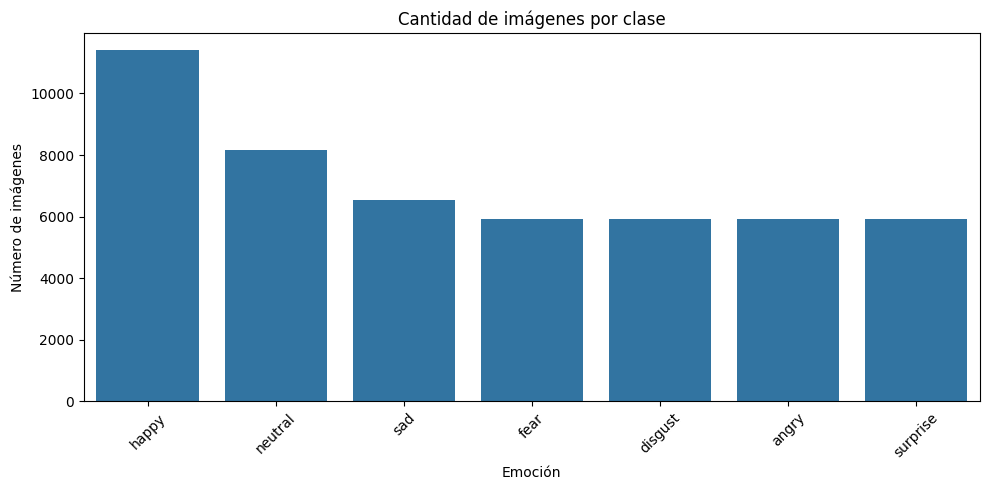

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(data=tabla_clases, x="Clase", y="Número de imágenes")
plt.title("Cantidad de imágenes por clase")
plt.xlabel("Emoción")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualización de ejemplos por clase
En esta sección se muestra una imagen de ejemplo por cada emoción para verificar que las carpetas estén bien organizadas y que las imágenes correspondan a la clase esperada.

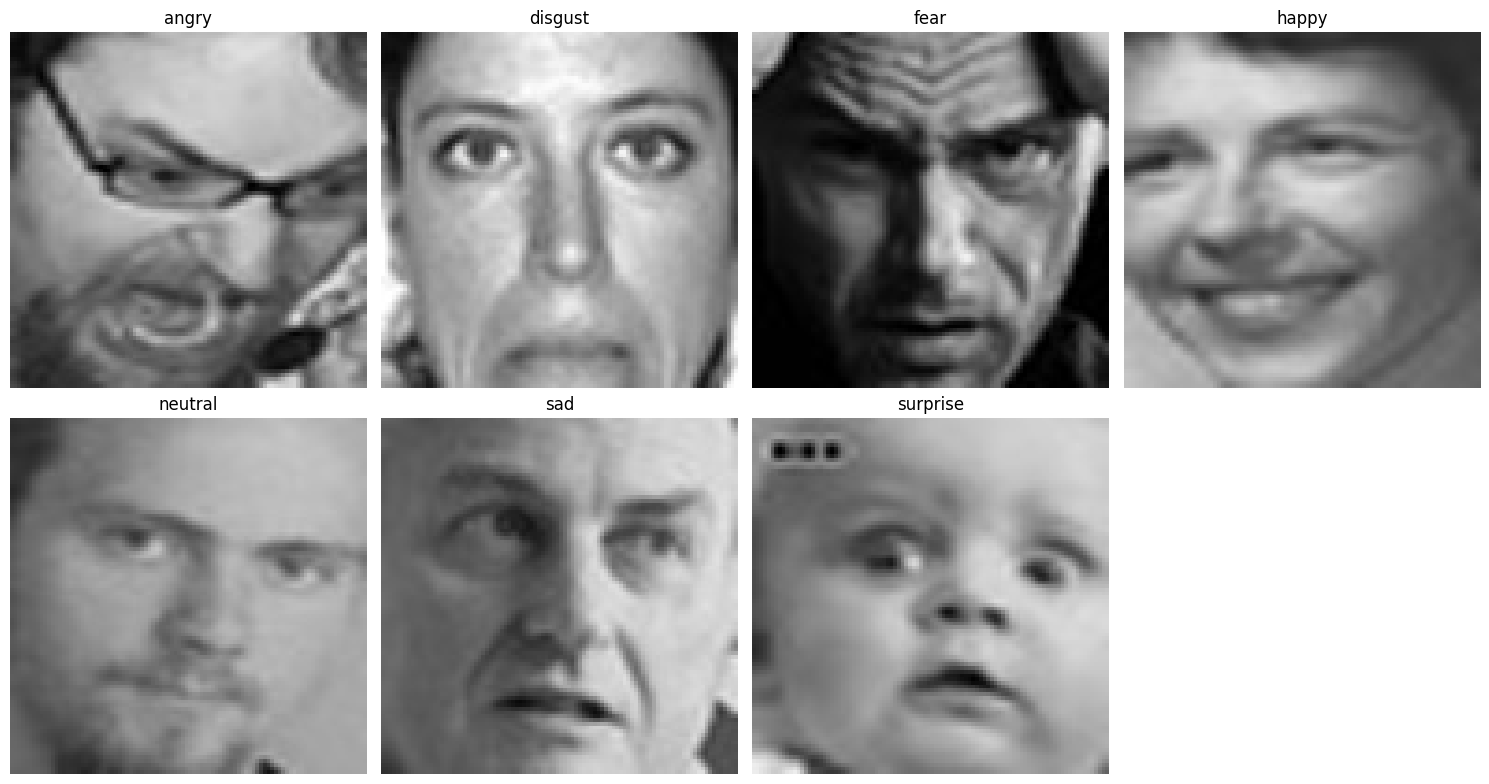

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Obtenemos las clases a partir de las carpetas dentro de raw
clases = sorted([carpeta.name for carpeta in ruta_dataset.iterdir() if carpeta.is_dir()])

# Creamos una figura para mostrar una imagen por clase
plt.figure(figsize=(15, 8))

# Recorremos las clases y mostramos la primera imagen encontrada en cada carpeta
for i, clase in enumerate(clases, 1):
    carpeta_clase = ruta_dataset / clase
    imagenes = list(carpeta_clase.glob("*.jpg"))
    
    # Tomamos la primera imagen de la carpeta
    img = Image.open(imagenes[0])
    
    # Mostramos la imagen en una subgráfica
    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.title(clase)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Visualización de varias imágenes aleatorias por clase
Aquí se muestran varios ejemplos aleatorios para observar mejor la variabilidad del conjunto de datos.

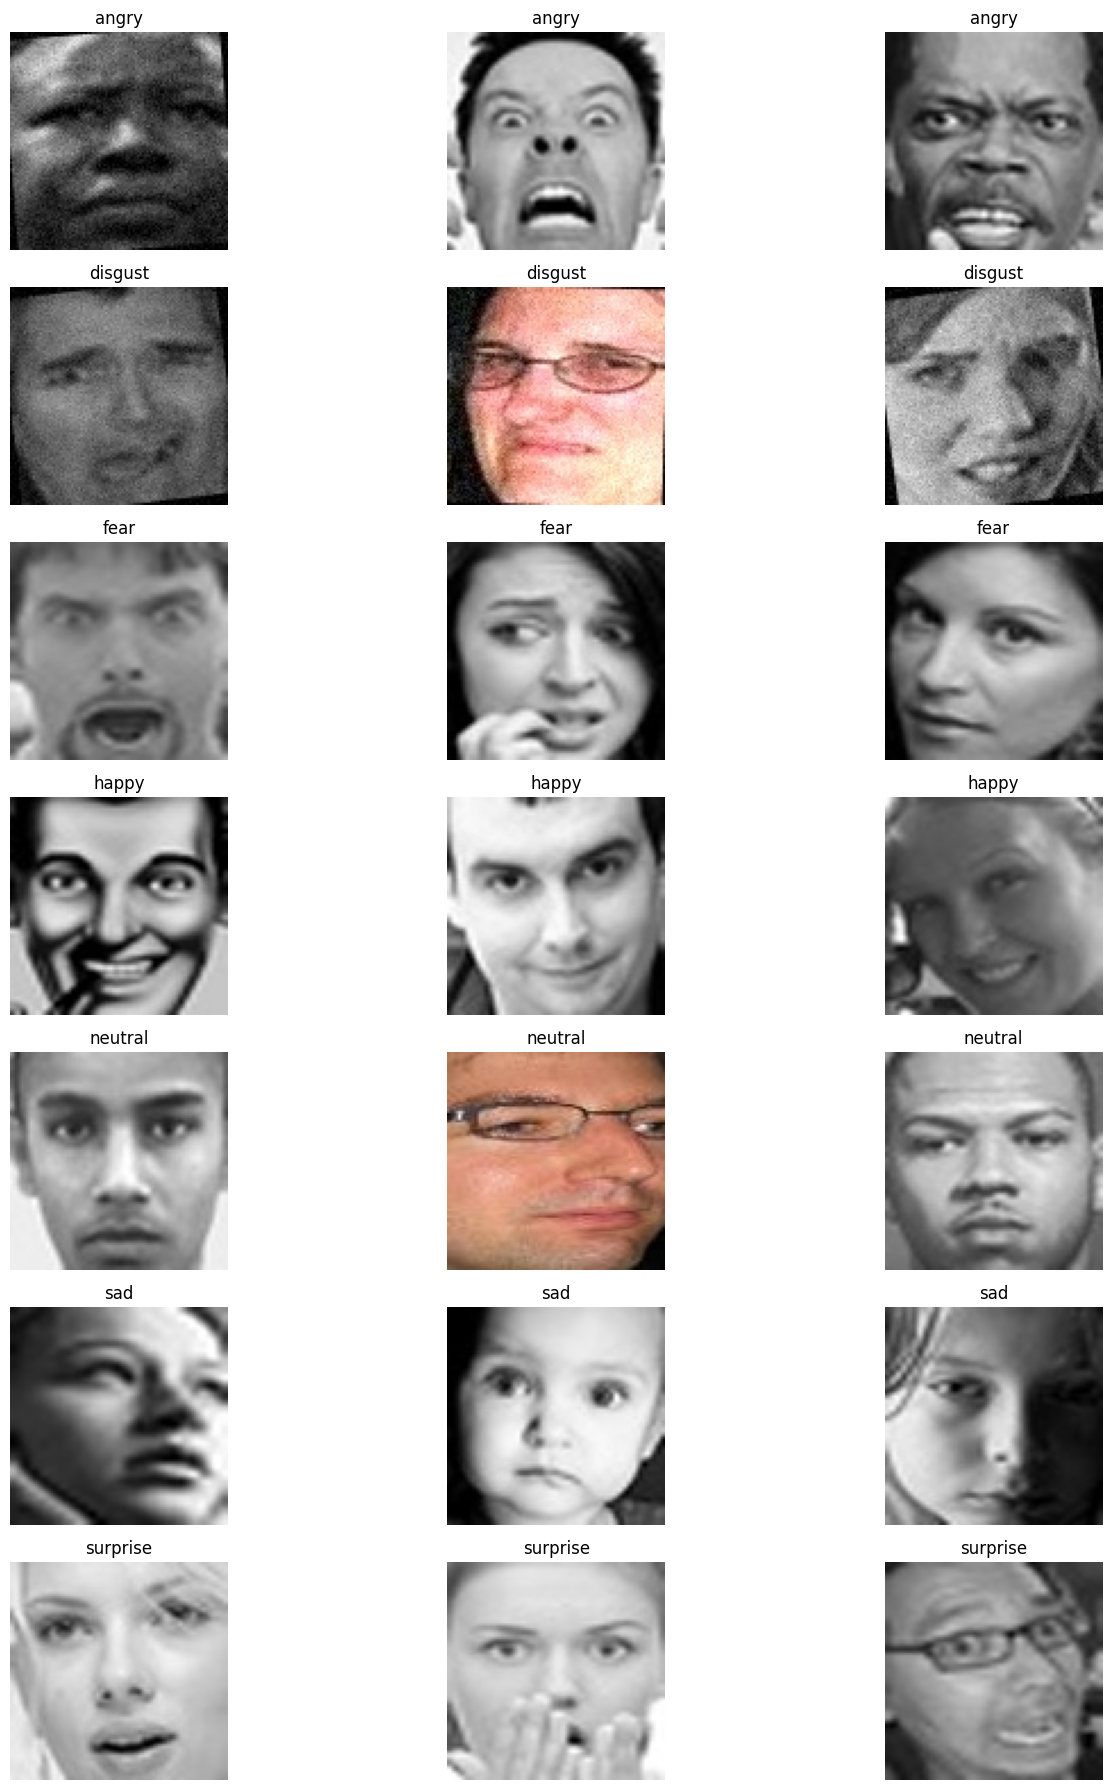

In [ ]:
import random

# Número de imágenes aleatorias por clase
n_imagenes = 3

# Creamos una figura grande
plt.figure(figsize=(15, 18))

contador = 1

# Recorremos cada clase
for clase in clases:
    carpeta_clase = ruta_dataset / clase
    imagenes = list(carpeta_clase.glob("*.jpg"))
    
    # Elegimos imágenes aleatorias
    seleccion = random.sample(imagenes, n_imagenes)
    
    for img_path in seleccion:
        img = Image.open(img_path)
        
        plt.subplot(len(clases), n_imagenes, contador)
        plt.imshow(img)
        plt.title(clase)
        plt.axis("off")
        
        contador += 1

plt.tight_layout()
plt.show()

## Revisión del tamaño de imágenes
En esta sección se revisan las dimensiones de algunas imágenes para identificar si el dataset tiene tamaños homogéneos o variables.

In [ ]:
# Lista para guardar tamaños de ejemplo
tamanos = []

# Revisamos hasta 5 imágenes por clase
for clase in clases:
    carpeta_clase = ruta_dataset / clase
    imagenes = list(carpeta_clase.glob("*.jpg"))[:5]
    
    for img_path in imagenes:
        img = Image.open(img_path)
        tamanos.append({
            "Clase": clase,
            "Archivo": img_path.name,
            "Ancho": img.size[0],
            "Alto": img.size[1]
        })

# Convertimos a DataFrame
tabla_tamanos = pd.DataFrame(tamanos)
tabla_tamanos

,Clase,Archivo,Ancho,Alto
0,angry,angry_00000.jpg,96,96
1,angry,angry_00001.jpg,96,96
2,angry,angry_00002.jpg,96,96
3,angry,angry_00003.jpg,96,96
4,angry,angry_00004.jpg,96,96
5,disgust,disgust_00000.jpg,96,96
6,disgust,disgust_00001.jpg,96,96
7,disgust,disgust_00002.jpg,96,96
8,disgust,disgust_00003.jpg,96,96
9,disgust,disgust_00004.jpg,96,96


In [ ]:
tabla_tamanos.groupby("Clase")[["Ancho", "Alto"]].agg(["min", "max", "mean"])

Ancho           Alto          
           min max  mean  min max  mean
Clase                                  
angry       96  96  96.0   96  96  96.0
disgust     96  96  96.0   96  96  96.0
fear        96  96  96.0   96  96  96.0
happy       96  96  96.0   96  96  96.0
neutral     96  96  96.0   96  96  96.0
sad         96  96  96.0   96  96  96.0
surprise    96  96  96.0   96  96  96.0

## Hallazgos
Durante la exploración visual se observó que, aunque todas las imágenes tienen dimensiones homogéneas, no todas presentan el mismo formato de color, ya que algunas están en escala de grises y otras en color. Este aspecto se considerará en la etapa de preprocesamiento para garantizar uniformidad en la entrada del modelo.

## Verificación de integridad y formato de las imágenes
En esta sección se revisa si las imágenes pueden abrirse correctamente y se registra información básica como clase, tamaño, modo de color y formato.

In [ ]:
from PIL import Image
from pathlib import Path
import pandas as pd

registros = []
imagenes_corruptas = []

# Recorremos cada carpeta de clase
for clase in clases:
    carpeta_clase = ruta_dataset / clase
    imagenes = list(carpeta_clase.glob("*.jpg"))
    
    for img_path in imagenes:
        try:
            with Image.open(img_path) as img:
                registros.append({
                    "Clase": clase,
                    "Archivo": img_path.name,
                    "Ancho": img.size[0],
                    "Alto": img.size[1],
                    "Modo": img.mode,
                    "Formato": img.format
                })
        except Exception as e:
            imagenes_corruptas.append({
                "Clase": clase,
                "Archivo": img_path.name,
                "Error": str(e)
            })

# Convertimos resultados a DataFrame
tabla_imagenes = pd.DataFrame(registros)
tabla_corruptas = pd.DataFrame(imagenes_corruptas)

print("Total de imágenes revisadas:", len(tabla_imagenes))
print("Total de imágenes corruptas:", len(tabla_corruptas))

Total de imágenes revisadas: 49779
Total de imágenes corruptas: 0


## Distribución del modo de color
Se analiza cuántas imágenes están en escala de grises, RGB u otros formatos de color.

In [ ]:
tabla_imagenes["Modo"].value_counts()

Modo
RGB    49779
Name: count, dtype: int64

In [ ]:
pd.crosstab(tabla_imagenes["Clase"], tabla_imagenes["Modo"])

Modo,RGB
Clase,
angry,5920
disgust,5920
fear,5920
happy,11398
neutral,8166
sad,6535
surprise,5920


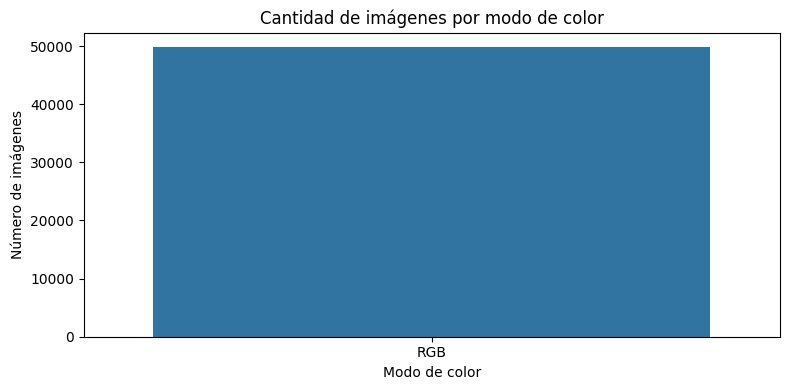

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

conteo_modos = tabla_imagenes["Modo"].value_counts().reset_index()
conteo_modos.columns = ["Modo", "Cantidad"]

plt.figure(figsize=(8, 4))
sns.barplot(data=conteo_modos, x="Modo", y="Cantidad")
plt.title("Cantidad de imágenes por modo de color")
plt.xlabel("Modo de color")
plt.ylabel("Número de imágenes")
plt.tight_layout()
plt.show()

No hay imágenes corruptas y todas están en formato RBG

## Confirmación global del tamaño de las imágenes
Se revisa si todas las imágenes del dataset mantienen las mismas dimensiones.

In [ ]:
tabla_imagenes[["Ancho", "Alto"]].drop_duplicates().sort_values(by=["Ancho", "Alto"])

,Ancho,Alto
0,96,96


## Conclusión del EDA
A partir de la revisión realizada, se observó que el dataset presenta una estructura consistente para continuar con el proyecto, ya que de las 49779, no se detectaron imágenes corruptas y todas pudieron abrirse correctamente. Además, se comprobó que todas las imágenes están en formato RGB y mantienen dimensiones homogéneas de 96 × 96 píxeles, lo cual es una ventaja para las siguientes etapas de preprocesamiento y modelado. En general, estos resultados indican que el conjunto de datos se encuentra en buenas condiciones y no requiere ajustes de limpieza importantes en esta fase inicial.
